# NAME: SEBA SAUD

# M4.Ex1: Housing Prices Model (PyCaret)

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M6/exercises/ex1_pycaret_regression.ipynb)

## Exercise

Your task is to follow the steps outlined here, and apply them on the **California Housing Dataset** below:

- [**🚀 Regression**](https://pycaret.gitbook.io/docs/get-started/quickstart#regression)
    - Setup
    - Compare Models
    - Analyze Model
    - Predictions
    - Save the model

## California Housing Prices Dataset


Find and download the dataset from Kaggle at [California Housing Dataset](https://www.kaggle.com/datasets/dhirajnirne/california-housing-data).

According to [keras.io](https://keras.io/api/datasets/california_housing/):

> This dataset was obtained from the StatLib repository.
>
> It's a continuous regression dataset with 20,640 samples with 8 features each.
>
> The target variable is a scalar: the median house value for California districts, in dollars.
>
> The 8 input features are the following:
>
> - MedInc: median income in block group
> - HouseAge: median house age in block group
> - AveRooms: average number of rooms per household
> - AveBedrms: average number of bedrooms per household
> - Population: block group population
> - AveOccup: average number of household members
> - Latitude: block group latitude
> - Longitude: block group longitude
>
> This dataset was derived from the 1990 U.S. census, using one row per census block group. A block group is the smallest geographical unit for which the U.S. Census Bureau publishes sample data (a block group typically has a population of 600 to 3,000 people).
>
> A household is a group of people residing within a home. Since the average number of rooms and bedrooms in this dataset are provided per household, these columns may take surprisingly large values for block groups with few households and many empty houses, such as vacation resorts.

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv('housing.csv')
print(data.head())
print(data.isnull().sum())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
longitude               0
latitude                0
housing_median_age     

### Load the data

In [60]:
import pandas as pd
data = pd.read_csv('housing.csv')



**Task**: Your model should learn from this data and be able to predict the median housing price (`median_house_value`) in any district, given all the other metrics.

Please read the above dataset description to understand what the features mean.

In [61]:

data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].median())
data = pd.get_dummies(data, drop_first=True)
print(data.head())


   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value  \
0       322.0       126.0         8.3252            452600.0   
1      2401.0      1138.0         8.3014            358500.0   
2       496.0       177.0         7.2574            352100.0   
3       558.0       219.0         5.6431            341300.0   
4       565.0       259.0         3.8462            342200.0   

   ocean_proximity_INLAND  ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0                   False                   False                      True   
1     

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
data = pd.get_dummies(data, drop_first=True)

X = data.drop('median_house_value', axis=1)
y = data['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


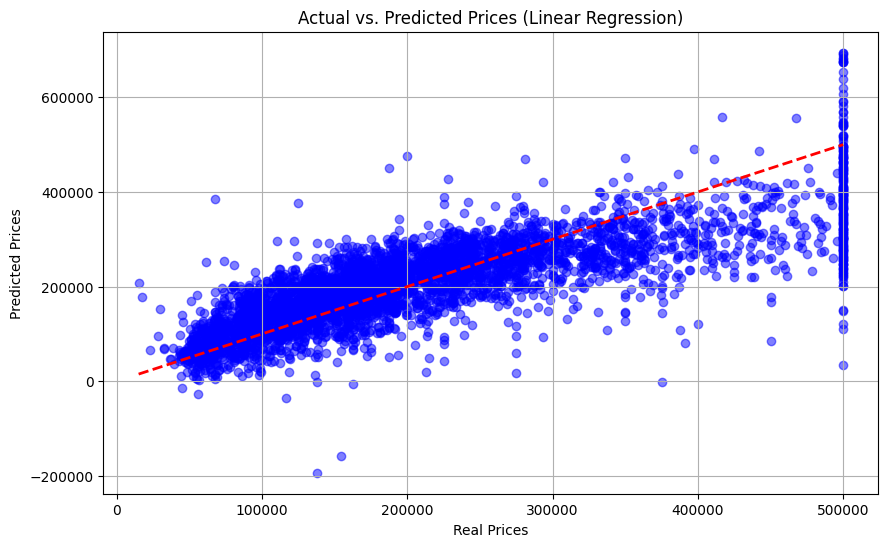

In [63]:
import matplotlib.pyplot as plt
predictions = model.predict(X_test)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, predictions, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) 

plt.xlabel('Real Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted Prices (Linear Regression)')
plt.grid(True)
plt.show()


In [64]:
from autogluon.tabular import TabularPredictor
label = 'median_house_value'

predictor = TabularPredictor(label=label).fit(
    train_data, 
    time_limit=60,           
    presets='medium_quality'    
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260422_082338"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.8
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       4.98 GB / 15.77 GB (31.6%)
Disk Space Avail:   157.21 GB / 475.71 GB (33.0%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\HP\OneDrive\Desktop\AAI\B5\student2\AutogluonModels\ag-20260422_082338"
Train Data Rows:    16512
Train Data Columns: 9
Label Column:       median_house_value
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, me

In [65]:

predictor.leaderboard(test_data)

performance = predictor.evaluate(test_data)
print(performance)

{'root_mean_squared_error': -48837.303269978394, 'mean_squared_error': -2385082190.6838427, 'mean_absolute_error': -33055.734574665395, 'r2': 0.8179894803616509, 'pearsonr': 0.904605856684181, 'median_absolute_error': -22401.2109375}


In [66]:
predictor.leaderboard(test_data)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,CatBoost,-48837.303270,-48531.806634,root_mean_squared_error,0.009770,0.010454,49.093080,0.009770,0.010454,49.093080,1,True,3
1,WeightedEnsemble_L2,-48837.303270,-48531.806634,root_mean_squared_error,0.013786,0.011367,49.104484,0.004016,0.000913,0.011404,2,True,4
2,LightGBMXT,-52274.473119,-52157.460200,root_mean_squared_error,0.090256,0.038021,8.591552,0.090256,0.038021,8.591552,1,True,1
3,LightGBM,-110624.780695,-115302.004585,root_mean_squared_error,0.006015,0.026770,0.588367,0.006015,0.026770,0.588367,1,True,2


In [67]:
performance = predictor.evaluate(test_data)
print(performance)

{'root_mean_squared_error': -48837.303269978394, 'mean_squared_error': -2385082190.6838427, 'mean_absolute_error': -33055.734574665395, 'r2': 0.8179894803616509, 'pearsonr': 0.904605856684181, 'median_absolute_error': -22401.2109375}


In [68]:
from sklearn.metrics import mean_squared_error
import numpy as np
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse) 
print(f"Root Mean Squared Error: {rmse}")

Root Mean Squared Error: 70060.52184473522
